
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_03_intuicion_estadistica_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Intuición estadística

**Jhonatan Jurado Rodríguez**

## Model Selection and Train/Validation/Test Sets
[1] Reference http://cs229.stanford.edu/syllabus.html

Just because a learning algorithm fits a training set well, that does not mean it is a good hypothesis. It could over fit and as a result your predictions on the test set would be poor. The error of your hypothesis as measured on the data set with which you trained the parameters will be lower than the error on any other data set.
Given many models with different complexities (for example polynomial degree), we can use a systematic approach to identify the 'best' function. In order to choose the model of your hypothesis, you can test each degree of polynomial and look at the error result.

One way to break down our dataset into the three sets is:
Training set: 60%
Cross validation set: 20%
Test set: 20%

We can now calculate three separate error values for the three different sets using the following method:
1. Optimize the parameters in Θ using the training set for each polynomial degree.
2. Find the polynomial degree d with the least error using the cross validation set.
3. Estimate the generalization error using the test set with J_{test}

This way, the degree of the polynomial d has not been trained using the test set.



## Para entregar


1. Para los modelos generados en la sesión 3 tomar el 20% como datos para realizar el test y el 80% para realizar el entrenamiento y la validacion cruzada (por ejemplo 70% entrenamiento y 10% validacion cruzada). Construir una curva del score en función del parámetro gamma del clasificador que se esta empleando. ¿Cual presenta una mejor solución al problema?.

2. Construir las curvas de aprendizaje estadístico para el modelo descrito, comprobar que la solución es similar a la que se obtiene a través de sklearn. GridSearch: https://scikit-learn.org/stable/modules/grid_search.html

3. Tomando el mejor modelo para los datos ahora van crear nuevos datasets donde el modelo se espera no va a ser optimo sino que presenta overfitting y underfitting. Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar graficamente un ejemplo de overfitting y uno de underfitting con el modelo óptimo anterior. Analizar los resultados.


## Desarrollo

In [1]:
# Librerias y funciones auxiliares (tomadas de la Sesión 03)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from matplotlib import cm
from sklearn.model_selection import train_test_split, ShuffleSplit, learning_curve, GridSearchCV
from sklearn.svm import SVC


def make_meshgrid(x, y, h=0.02):
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy


def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out


def data(mu=[1,1], mu1=[-2,2], cov=[[1.0, 0.0], [0.0, 1.0]], cov1=[[1.0, -0.5], [-0.5, 1.0]]):
    rv = multivariate_normal(mu, cov)
    rv1 = multivariate_normal(mu1, cov1)
    return rv, rv1


def sample(rv, rv1, N1=1000, N2=100, r=0.2):
    X_t = np.concatenate([rv.rvs(N1, random_state=r), rv1.rvs(N2, random_state=r)])
    y = np.concatenate([np.zeros(N1), np.ones(N2)])
    return X_t, y


def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(0.1, 1.0, 5)):
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")
    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)
    axes[0].grid()
    axes[0].fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1, color="r")
    axes[0].fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1, color="g")
    axes[0].plot(train_sizes, train_scores_mean, "o-", color="r", label="Training score")
    axes[0].plot(train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation score")
    axes[0].legend(loc="best")
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, "o-")
    axes[1].fill_between(train_sizes, fit_times_mean - fit_times_std,
                         fit_times_mean + fit_times_std, alpha=0.1)
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, "o-")
    axes[2].fill_between(fit_times_mean, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1)
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")
    return plt

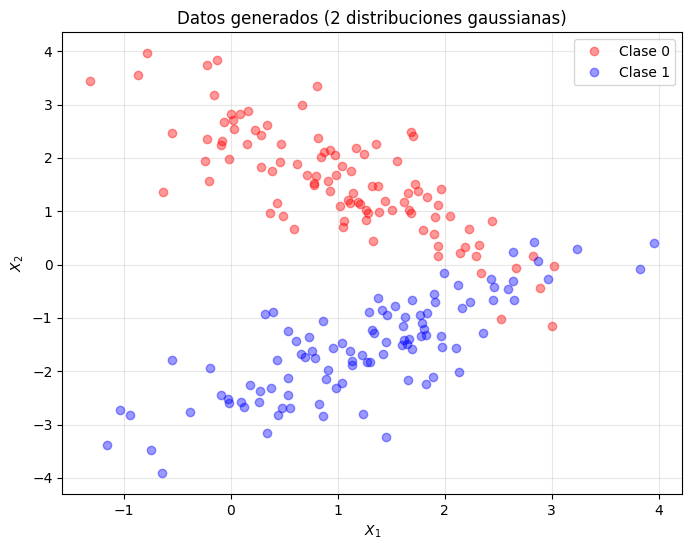

Total de datos: 200
Datos de entrenamiento+validación: 160
Datos de test: 40


In [2]:
# Generar los datos con los mismos parámetros de la sesión 03
rv, rv1 = data(mu=[1.2, 1.4], mu1=[1.4, -1.4],
               cov=[[1.0, -0.8], [-0.8, 1.0]],
               cov1=[[1.0, 0.8], [0.8, 1.0]])

X_t, y = sample(rv, rv1, N1=100, N2=100, r=10)

# Separar 20% test, 80% train+validación
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_t, y, test_size=0.2, random_state=42)

# Visualizar los datos generados
plt.figure(figsize=(8, 6))
plt.plot(X_t[y == 0][:, 0], X_t[y == 0][:, 1], "ro", alpha=0.4, label="Clase 0")
plt.plot(X_t[y == 1][:, 0], X_t[y == 1][:, 1], "bo", alpha=0.4, label="Clase 1")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Datos generados (2 distribuciones gaussianas)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Total de datos: {len(X_t)}")
print(f"Datos de entrenamiento+validación: {len(X_train_full)}")
print(f"Datos de test: {len(X_test)}")

## Punto 1: Curva de Score vs Gamma

Se toma el 20% como datos de test y el 80% restante para entrenamiento y validación cruzada.
Se entrena un clasificador SVC variando el hiperparámetro $\gamma$ y se construye la curva de score en función de $\gamma$.

Mejor gamma (CV): 0.0015
Score CV en mejor gamma: 0.9500
Score Test en mejor gamma: 0.9500


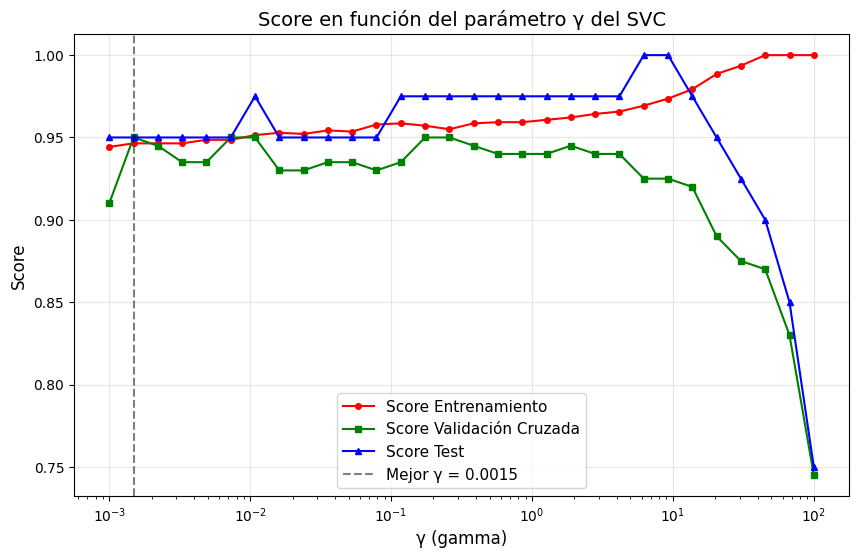

In [3]:
# Barrido de gamma para SVC
gammas = np.logspace(-3, 2, 30)  # gamma de 0.001 a 100

train_scores_gamma = []
cv_scores_gamma = []
test_scores_gamma = []

cv = ShuffleSplit(n_splits=10, test_size=0.125, random_state=42)
# 0.125 del 80% ≈ 10% del total → 70% train, 10% CV

for g in gammas:
    train_sc = []
    cv_sc = []
    for train_idx, val_idx in cv.split(X_train_full):
        X_tr, X_val = X_train_full[train_idx], X_train_full[val_idx]
        y_tr, y_val = y_train_full[train_idx], y_train_full[val_idx]
        clf = SVC(gamma=g)
        clf.fit(X_tr, y_tr)
        train_sc.append(clf.score(X_tr, y_tr))
        cv_sc.append(clf.score(X_val, y_val))
    train_scores_gamma.append(np.mean(train_sc))
    cv_scores_gamma.append(np.mean(cv_sc))
    # Score en test con modelo entrenado en todo el train_full
    clf_full = SVC(gamma=g)
    clf_full.fit(X_train_full, y_train_full)
    test_scores_gamma.append(clf_full.score(X_test, y_test))

train_scores_gamma = np.array(train_scores_gamma)
cv_scores_gamma = np.array(cv_scores_gamma)
test_scores_gamma = np.array(test_scores_gamma)

# Mejor gamma según validación cruzada
best_idx = np.argmax(cv_scores_gamma)
best_gamma = gammas[best_idx]
print(f"Mejor gamma (CV): {best_gamma:.4f}")
print(f"Score CV en mejor gamma: {cv_scores_gamma[best_idx]:.4f}")
print(f"Score Test en mejor gamma: {test_scores_gamma[best_idx]:.4f}")

# Gráfica Score vs Gamma
plt.figure(figsize=(10, 6))
plt.semilogx(gammas, train_scores_gamma, "r-o", label="Score Entrenamiento", markersize=4)
plt.semilogx(gammas, cv_scores_gamma, "g-s", label="Score Validación Cruzada", markersize=4)
plt.semilogx(gammas, test_scores_gamma, "b-^", label="Score Test", markersize=4)
plt.axvline(x=best_gamma, color="k", linestyle="--", alpha=0.5, label=f"Mejor γ = {best_gamma:.4f}")
plt.xlabel("γ (gamma)", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Score en función del parámetro γ del SVC", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

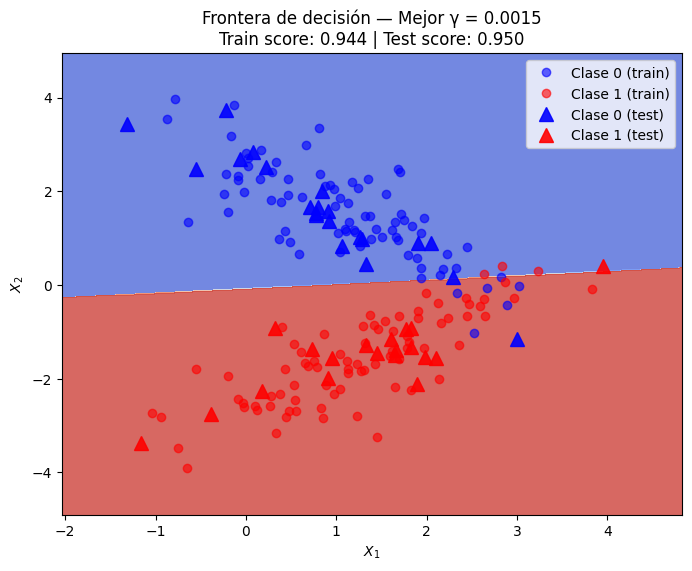

In [4]:
# Frontera de decisión con el mejor gamma
clf_best = SVC(gamma=best_gamma)
clf_best.fit(X_train_full, y_train_full)

fig, ax = plt.subplots(figsize=(8, 6))
X0, X1 = X_train_full[:, 0], X_train_full[:, 1]
xx, yy = make_meshgrid(X0, X1)
plot_contours(ax, clf_best, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax.plot(X_train_full[y_train_full == 0][:, 0], X_train_full[y_train_full == 0][:, 1],
        "bo", alpha=0.6, label="Clase 0 (train)")
ax.plot(X_train_full[y_train_full == 1][:, 0], X_train_full[y_train_full == 1][:, 1],
        "ro", alpha=0.6, label="Clase 1 (train)")
ax.plot(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
        "b^", markersize=10, alpha=0.9, label="Clase 0 (test)")
ax.plot(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
        "r^", markersize=10, alpha=0.9, label="Clase 1 (test)")
ax.set_title(f"Frontera de decisión — Mejor γ = {best_gamma:.4f}\n"
             f"Train score: {clf_best.score(X_train_full, y_train_full):.3f} | "
             f"Test score: {clf_best.score(X_test, y_test):.3f}", fontsize=12)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.legend()
plt.show()

## Punto 2: Curvas de aprendizaje y GridSearchCV

Se construyen las curvas de aprendizaje para el modelo con el mejor $\gamma$ encontrado y se compara con el resultado obtenido mediante `sklearn.model_selection.GridSearchCV`.

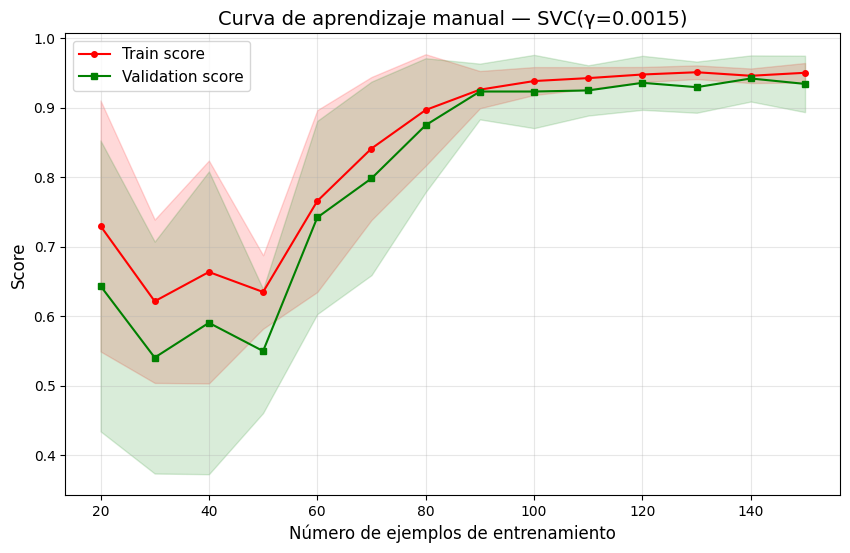

In [5]:
# Curvas de aprendizaje con el mejor gamma (construcción manual como en sesión 03)
clf_opt = SVC(gamma=best_gamma)
sizes = np.arange(20, len(X_train_full), 10)

train_score_manual = []
val_score_manual = []
train_std_manual = []
val_std_manual = []

for s in sizes:
    tr_scores = []
    vl_scores = []
    for _ in range(20):
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train_full, y_train_full, test_size=0.2)
        idx = np.random.permutation(len(X_tr))[:s]
        clf_temp = SVC(gamma=best_gamma)
        clf_temp.fit(X_tr[idx], y_tr[idx])
        tr_scores.append(clf_temp.score(X_tr[idx], y_tr[idx]))
        vl_scores.append(clf_temp.score(X_val, y_val))
    train_score_manual.append(np.mean(tr_scores))
    val_score_manual.append(np.mean(vl_scores))
    train_std_manual.append(np.std(tr_scores))
    val_std_manual.append(np.std(vl_scores))

train_score_manual = np.array(train_score_manual)
val_score_manual = np.array(val_score_manual)
train_std_manual = np.array(train_std_manual)
val_std_manual = np.array(val_std_manual)

plt.figure(figsize=(10, 6))
plt.plot(sizes, train_score_manual, "r-o", label="Train score", markersize=4)
plt.fill_between(sizes, train_score_manual - train_std_manual,
                 train_score_manual + train_std_manual, alpha=0.15, color="r")
plt.plot(sizes, val_score_manual, "g-s", label="Validation score", markersize=4)
plt.fill_between(sizes, val_score_manual - val_std_manual,
                 val_score_manual + val_std_manual, alpha=0.15, color="g")
plt.xlabel("Número de ejemplos de entrenamiento", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title(f"Curva de aprendizaje manual — SVC(γ={best_gamma:.4f})", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

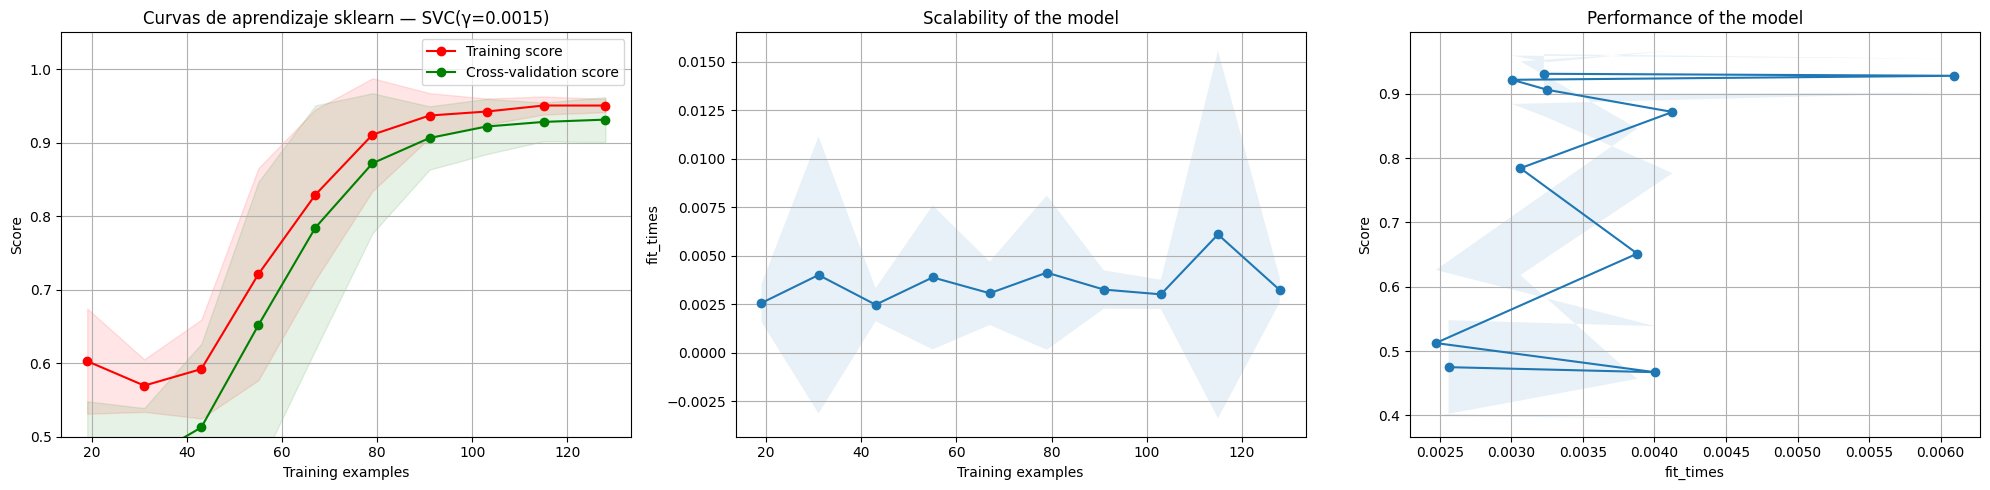

In [6]:
# Curvas de aprendizaje con sklearn (para comparar con la construcción manual)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
cv_lc = ShuffleSplit(n_splits=20, test_size=0.2, random_state=0)

plot_learning_curve(
    SVC(gamma=best_gamma),
    f"Curvas de aprendizaje sklearn — SVC(γ={best_gamma:.4f})",
    X_train_full, y_train_full,
    axes=axes, ylim=(0.5, 1.05), cv=cv_lc, n_jobs=-1,
    train_sizes=np.linspace(0.15, 1.0, 10)
)
plt.tight_layout()
plt.show()

Mejor gamma (GridSearchCV): 0.0073
Mejor score CV (GridSearchCV): 0.9500
Score en Test (GridSearchCV): 0.9500

Comparación:
  Gamma manual:      0.0015  |  Gamma GridSearch: 0.0073
  Score CV manual:   0.9500  |  Score CV GridSearch: 0.9500


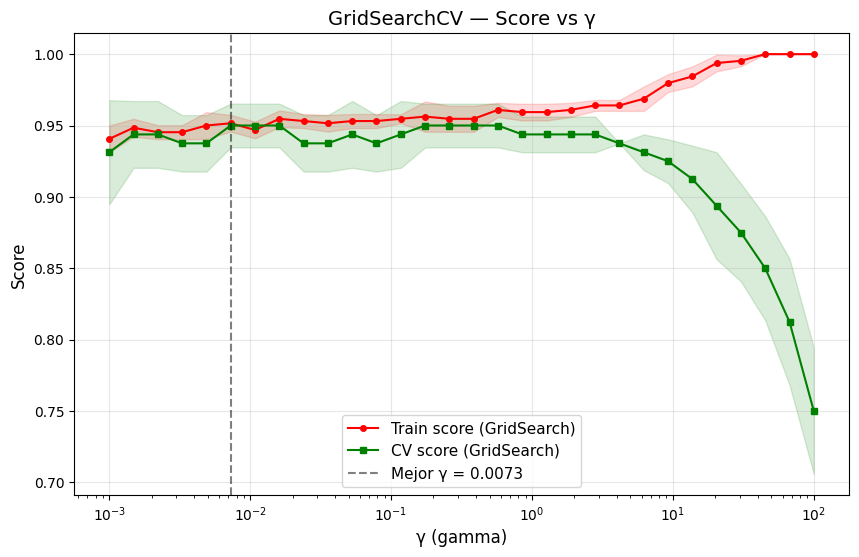

In [7]:
# Comparación con GridSearchCV
param_grid = {'gamma': np.logspace(-3, 2, 30)}
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', return_train_score=True)
grid_search.fit(X_train_full, y_train_full)

print(f"Mejor gamma (GridSearchCV): {grid_search.best_params_['gamma']:.4f}")
print(f"Mejor score CV (GridSearchCV): {grid_search.best_score_:.4f}")
print(f"Score en Test (GridSearchCV): {grid_search.score(X_test, y_test):.4f}")
print(f"\nComparación:")
print(f"  Gamma manual:      {best_gamma:.4f}  |  Gamma GridSearch: {grid_search.best_params_['gamma']:.4f}")
print(f"  Score CV manual:   {cv_scores_gamma[best_idx]:.4f}  |  Score CV GridSearch: {grid_search.best_score_:.4f}")

# Gráfica de GridSearchCV
results = grid_search.cv_results_
plt.figure(figsize=(10, 6))
plt.semilogx(param_grid['gamma'], results['mean_train_score'], "r-o", label="Train score (GridSearch)", markersize=4)
plt.fill_between(param_grid['gamma'],
                 results['mean_train_score'] - results['std_train_score'],
                 results['mean_train_score'] + results['std_train_score'], alpha=0.15, color="r")
plt.semilogx(param_grid['gamma'], results['mean_test_score'], "g-s", label="CV score (GridSearch)", markersize=4)
plt.fill_between(param_grid['gamma'],
                 results['mean_test_score'] - results['std_test_score'],
                 results['mean_test_score'] + results['std_test_score'], alpha=0.15, color="g")
plt.axvline(x=grid_search.best_params_['gamma'], color="k", linestyle="--", alpha=0.5,
            label=f"Mejor γ = {grid_search.best_params_['gamma']:.4f}")
plt.xlabel("γ (gamma)", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("GridSearchCV — Score vs γ", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## Punto 3: Overfitting y Underfitting con nuevos datasets

Se toma el mejor modelo (SVC con el $\gamma$ óptimo encontrado) y se crean nuevos datasets donde se espera que el modelo **no sea óptimo**:

- **Overfitting**: Distribuciones muy separadas con pocos datos. El modelo con $\gamma$ alto tiende a memorizar los datos de entrenamiento, generando una frontera de decisión demasiado compleja.
- **Underfitting**: Distribuciones muy superpuestas donde la frontera óptima es más compleja de lo que el modelo con $\gamma$ bajo puede capturar.

### 3a) Ejemplo de Overfitting

Se usa un $\gamma$ alto (=20) con pocos datos y distribuciones bien separadas. El modelo memoriza los datos de entrenamiento y genera una frontera excesivamente compleja.

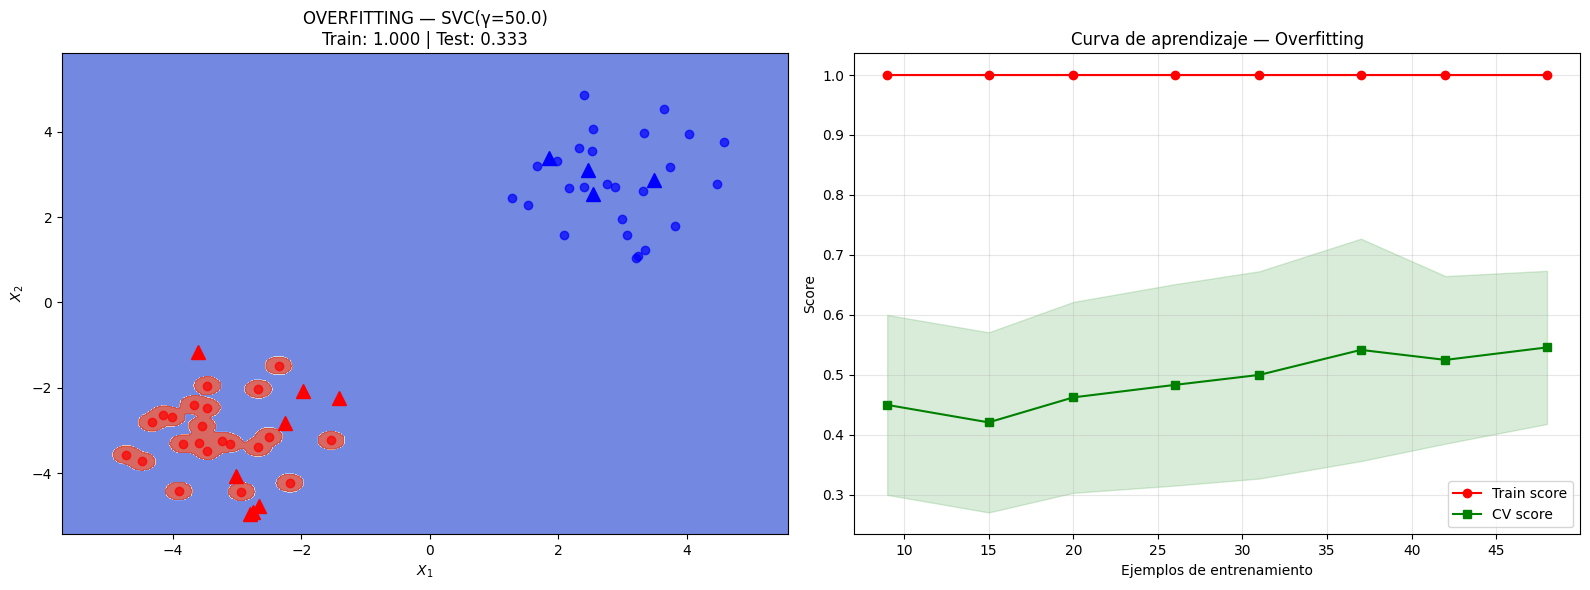

Score Train: 1.000
Score Test:  0.333
→ El score de entrenamiento es muy alto pero el de test es menor,
  indicando que el modelo memoriza los datos (overfitting).


In [8]:
# Dataset para OVERFITTING: distribuciones separadas, pocos datos, gamma alto
rv_of, rv1_of = data(
    mu=[3.0, 3.0], mu1=[-3.0, -3.0],
    cov=[[1.0, 0.0], [0.0, 1.0]],
    cov1=[[1.0, 0.0], [0.0, 1.0]]
)
X_of, y_of = sample(rv_of, rv1_of, N1=30, N2=30, r=42)

X_train_of, X_test_of, y_train_of, y_test_of = train_test_split(
    X_of, y_of, test_size=0.2, random_state=42)

gamma_overfit = 50.0  # Gamma muy alto → frontera demasiado compleja
clf_of = SVC(gamma=gamma_overfit)
clf_of.fit(X_train_of, y_train_of)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frontera de decisión
X0, X1 = X_train_of[:, 0], X_train_of[:, 1]
xx, yy = make_meshgrid(X0, X1)
plot_contours(axes[0], clf_of, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
axes[0].plot(X_train_of[y_train_of == 0][:, 0], X_train_of[y_train_of == 0][:, 1], "bo", alpha=0.7)
axes[0].plot(X_train_of[y_train_of == 1][:, 0], X_train_of[y_train_of == 1][:, 1], "ro", alpha=0.7)
axes[0].plot(X_test_of[y_test_of == 0][:, 0], X_test_of[y_test_of == 0][:, 1], "b^", markersize=10)
axes[0].plot(X_test_of[y_test_of == 1][:, 0], X_test_of[y_test_of == 1][:, 1], "r^", markersize=10)
axes[0].set_title(f"OVERFITTING — SVC(γ={gamma_overfit})\n"
                  f"Train: {clf_of.score(X_train_of, y_train_of):.3f} | "
                  f"Test: {clf_of.score(X_test_of, y_test_of):.3f}", fontsize=12)
axes[0].set_xlabel("$X_1$")
axes[0].set_ylabel("$X_2$")

# Curva de aprendizaje para overfitting
cv_of = ShuffleSplit(n_splits=20, test_size=0.2, random_state=0)
train_sizes_of, train_sc_of, test_sc_of = learning_curve(
    SVC(gamma=gamma_overfit), X_of, y_of, cv=cv_of, n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 8))
axes[1].plot(train_sizes_of, np.mean(train_sc_of, axis=1), "r-o", label="Train score")
axes[1].fill_between(train_sizes_of,
                     np.mean(train_sc_of, axis=1) - np.std(train_sc_of, axis=1),
                     np.mean(train_sc_of, axis=1) + np.std(train_sc_of, axis=1), alpha=0.15, color="r")
axes[1].plot(train_sizes_of, np.mean(test_sc_of, axis=1), "g-s", label="CV score")
axes[1].fill_between(train_sizes_of,
                     np.mean(test_sc_of, axis=1) - np.std(test_sc_of, axis=1),
                     np.mean(test_sc_of, axis=1) + np.std(test_sc_of, axis=1), alpha=0.15, color="g")
axes[1].set_title("Curva de aprendizaje — Overfitting", fontsize=12)
axes[1].set_xlabel("Ejemplos de entrenamiento")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Score Train: {clf_of.score(X_train_of, y_train_of):.3f}")
print(f"Score Test:  {clf_of.score(X_test_of, y_test_of):.3f}")
print("→ El score de entrenamiento es muy alto pero el de test es menor,")
print("  indicando que el modelo memoriza los datos (overfitting).")

### 3b) Ejemplo de Underfitting

Se usa un $\gamma$ muy bajo (=0.001) con distribuciones superpuestas. El modelo no puede capturar la complejidad de la frontera y presenta un error alto tanto en entrenamiento como en test.

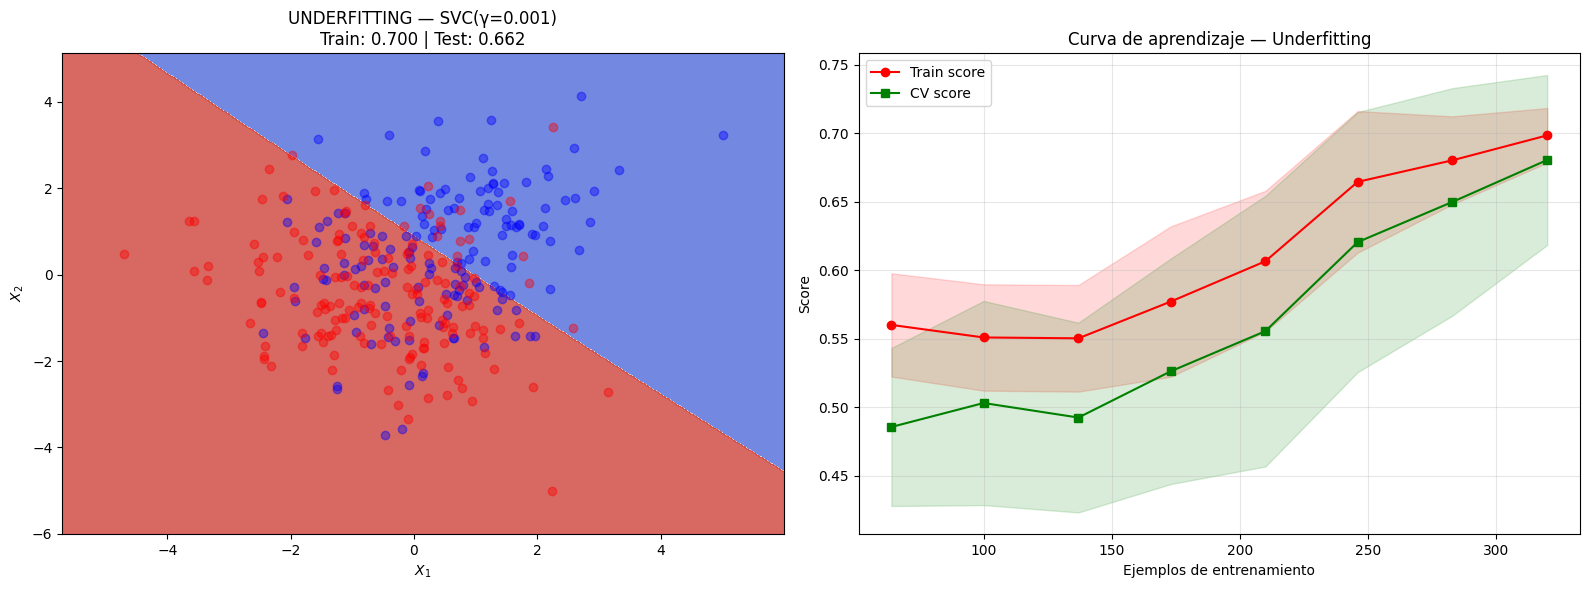

Score Train: 0.700
Score Test:  0.662
→ Ambos scores son bajos y similares, indicando que el modelo
  no puede capturar la estructura de los datos (underfitting).


In [9]:
# Dataset para UNDERFITTING: distribuciones muy superpuestas, gamma muy bajo
rv_uf, rv1_uf = data(
    mu=[0.5, 0.5], mu1=[-0.5, -0.5],
    cov=[[2.0, 0.5], [0.5, 2.0]],
    cov1=[[2.0, -0.5], [-0.5, 2.0]]
)
X_uf, y_uf = sample(rv_uf, rv1_uf, N1=200, N2=200, r=42)

X_train_uf, X_test_uf, y_train_uf, y_test_uf = train_test_split(
    X_uf, y_uf, test_size=0.2, random_state=42)

gamma_underfit = 0.001  # Gamma muy bajo → frontera demasiado simple
clf_uf = SVC(gamma=gamma_underfit)
clf_uf.fit(X_train_uf, y_train_uf)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Frontera de decisión
X0, X1 = X_train_uf[:, 0], X_train_uf[:, 1]
xx, yy = make_meshgrid(X0, X1)
plot_contours(axes[0], clf_uf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
axes[0].plot(X_train_uf[y_train_uf == 0][:, 0], X_train_uf[y_train_uf == 0][:, 1], "bo", alpha=0.4)
axes[0].plot(X_train_uf[y_train_uf == 1][:, 0], X_train_uf[y_train_uf == 1][:, 1], "ro", alpha=0.4)
axes[0].set_title(f"UNDERFITTING — SVC(γ={gamma_underfit})\n"
                  f"Train: {clf_uf.score(X_train_uf, y_train_uf):.3f} | "
                  f"Test: {clf_uf.score(X_test_uf, y_test_uf):.3f}", fontsize=12)
axes[0].set_xlabel("$X_1$")
axes[0].set_ylabel("$X_2$")

# Curva de aprendizaje para underfitting
cv_uf = ShuffleSplit(n_splits=20, test_size=0.2, random_state=0)
train_sizes_uf, train_sc_uf, test_sc_uf = learning_curve(
    SVC(gamma=gamma_underfit), X_uf, y_uf, cv=cv_uf, n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 8))
axes[1].plot(train_sizes_uf, np.mean(train_sc_uf, axis=1), "r-o", label="Train score")
axes[1].fill_between(train_sizes_uf,
                     np.mean(train_sc_uf, axis=1) - np.std(train_sc_uf, axis=1),
                     np.mean(train_sc_uf, axis=1) + np.std(train_sc_uf, axis=1), alpha=0.15, color="r")
axes[1].plot(train_sizes_uf, np.mean(test_sc_uf, axis=1), "g-s", label="CV score")
axes[1].fill_between(train_sizes_uf,
                     np.mean(test_sc_uf, axis=1) - np.std(test_sc_uf, axis=1),
                     np.mean(test_sc_uf, axis=1) + np.std(test_sc_uf, axis=1), alpha=0.15, color="g")
axes[1].set_title("Curva de aprendizaje — Underfitting", fontsize=12)
axes[1].set_xlabel("Ejemplos de entrenamiento")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Score Train: {clf_uf.score(X_train_uf, y_train_uf):.3f}")
print(f"Score Test:  {clf_uf.score(X_test_uf, y_test_uf):.3f}")
print("→ Ambos scores son bajos y similares, indicando que el modelo")
print("  no puede capturar la estructura de los datos (underfitting).")

### Análisis de resultados

**Overfitting (γ alto):**
- El score de entrenamiento es cercano a 1.0, pero el score de test es significativamente menor.
- La curva de aprendizaje muestra una gran brecha entre el score de entrenamiento y el de validación.
- La frontera de decisión es excesivamente compleja, adaptándose al ruido de los datos de entrenamiento.
- Esto se produce porque un $\gamma$ alto hace que cada punto de entrenamiento tenga una influencia muy localizada, generando "islas" de clasificación.

**Underfitting (γ bajo):**
- Tanto el score de entrenamiento como el de test son bajos y similares.
- La curva de aprendizaje muestra que ambas curvas convergen a un valor bajo y no mejoran con más datos.
- La frontera de decisión es demasiado simple (casi lineal) y no captura la verdadera estructura de separación entre clases.
- Un $\gamma$ muy bajo hace que la influencia de cada punto sea demasiado amplia, produciendo una frontera suavizada que ignora la distribución real.

**Modelo óptimo:**
- El $\gamma$ óptimo encontrado en el Punto 1 balancea la complejidad del modelo, logrando scores similares en entrenamiento y test.
- Las curvas de aprendizaje muestran convergencia de ambas curvas a un valor alto, indicando buena generalización.